# Quantization and Sampling Effects


## Goal
Show how encoder/decoder resolution and sampling period affect tracking accuracy.

## Model Map
- `SineAngleSetPoint` → `PIDContinuous` → `DriveDynamic` → `Pendulum`
- Measurement path: `MasterPendulum.theta` → `AnglePotentiometerADC` → `AnglePotentiometerADCDecoder` → `PIDContinuous`

![System Graph](figures/graphs/02_quantization_graph.svg)

## Assumptions and Scope
- No wall contact
- Fixed-step co-simulation; reference uses variable-step DASSL

## Prerequisites and Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from OMPython import ModelicaSystem

from syssimx import FMUComponent, Connection, System, SystemGraphVisualizer

## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
        for subsubdir in subdir.iterdir():
            fmu_paths[subdir.name][subsubdir.name] = {}
            if subsubdir.is_dir():
                fmu_paths[subdir.name][subsubdir.name] = {}
                for fmu_file in subsubdir.glob("*.fmu"):
                    fmu_paths[subdir.name][subsubdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

## Modelica Reference Simulation (Monolithic)

```Modelica
within ControlledPendulum.Examples.NoContact;

model Quantization
  // Type definitions
  type RealOutput = Modelica.Blocks.Interfaces.RealOutput;

  // Components
  Trajectories.SineAngleSetPoint       set_point;
  Sensors.AnglePotentiometerADC        angle_sensor;
  Sensors.AnglePotentiometerADCDecoder angle_decoder;
  Controllers.PIDContinuous            pid;
  Actuators.DriveDynamic               drive;
  Plants.Pendulum                      pendulum;

  // FMUCompoent observables
  RealOutput theta_ref(unit="rad") "Reference angle from set point";
  RealOutput theta_meas(unit="rad") "Measured angle from sensor";
  RealOutput theta(unit="rad") "Measured angle from pendulum";
  RealOutput omega(unit="rad/s") "Measured angle from pendulum"; 
  RealOutput alpha(unit="rad/s2") "Measured angle from pendulum";  
  RealOutput u_control(unit="1") "Control input from PID";
  RealOutput tau(unit="N.m") "Torque from drive";

equation
  // Connections
  connect(set_point.theta_ref, pid.theta_ref);
  connect(pendulum.theta, angle_sensor.theta);
  connect(angle_sensor.v_out, angle_decoder.v_in);
  connect(angle_decoder.theta, pid.theta_meas);
  connect(pid.u, drive.u_control);
  connect(drive.torque, pendulum.tau);
  connect(drive.omega, pendulum.omega);
  
  // Observables
  theta_ref = set_point.theta_ref;
  theta_meas = angle_decoder.theta;
  theta = pendulum.theta;
  omega = pendulum.omega;
  alpha = pendulum.alpha;
  u_control = pid.u;
  tau = drive.torque;  
  
  pid.resetI = false; // No contact - reset not required
  
  annotation(
    experiment(StartTime = 0, StopTime = 5, Interval = 0.001)
  );

end Quantization;

In [4]:
reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.Quantization")
reference.buildModel()


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




### Reference Sensor Parameters

In [5]:
ref_params = reference.getParameters()

ref_sensor_params = {
    "nBits": int(ref_params['angle_sensor.nBits']),
    "samplePeriod": float(ref_params['angle_sensor.samplePeriod']),
    "decoder_nBits": int(ref_params['angle_decoder.nBits']),
    "decoder_samplePeriod": float(ref_params['angle_decoder.samplePeriod']),
}

print("Reference sensor parameters →")
print(f"  nBits: {ref_sensor_params['nBits']}")
print(f"  samplePeriod [s]: {ref_sensor_params['samplePeriod']}")


Reference sensor parameters →
  nBits: 10
  samplePeriod [s]: 0.01


### Run Reference Simulation

In [6]:
reference.simulate()
ref_sol_names = ('time', 'theta', 'theta_meas')
ref_sol = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


## Instantiate FMU Components

In [7]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        print(f"  - {name}: {param}")

In [8]:
set_point = FMUComponent(name="SineAngle",
                         fmu_path=fmu_paths['Trajectories']["SineAngleSetPoint"],
                         group="Target Trajectory")
print_parameteres(set_point)

Parameters of SineAngle:
  - amplitude: 0.3490658503988659 rad
  - frequency: 0.25 Hz
  - offset: 0.0 rad
  - phase: 0.0 rad
  - startTime: 0.0 s


In [9]:
pid = FMUComponent(name="PID",
                   fmu_path=fmu_paths['Controllers']["PIDContinuous_cvode"],
                   group="Control")
print_parameteres(pid)

Parameters of PID:
  - D.T: None
  - D.k: None
  - D.x_start: 0.0
  - D.y_start: 0.0
  - I.k: None
  - I.outMax: None
  - I.outMin: None
  - I.y_start: 0.0
  - Kd: 0.01
  - Ki: 5.0
  - Kp: 20.0
  - Nd: 10.0
  - P.k: None
  - Td: 0.6
  - addErr.k1: 1.0
  - addErr.k2: -1.0
  - lim.uMax: None
  - lim.uMin: None
  - sumPID.k1: 1.0
  - sumPID.k2: 1.0
  - sumPID.k3: 1.0
  - uMax: 1.0
  - uMin: -1.0
  - D.initType: None
  - I.initType: None
  - lim.homotopyType: None
  - I.limitsAtInit: None
  - I.strict: None
  - I.use_reset: None
  - I.use_set: None
  - lim.strict: None


In [10]:
drive = FMUComponent(name="BLDC Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")
print_parameteres(drive)

Parameters of BLDC Drive:
  - I_max: 10.0 A
  - L_arm: 0.000121 H
  - R_arm: 0.151 Ohm
  - V_rated: 48.0 V
  - V_supply: 16.0 V
  - eta: 0.85
  - gearRatio: 60.0
  - k_e: None
  - k_n: None
  - k_t: 0.03 m·N/A
  - n_0: 12916.0 1/min


In [11]:
pendulum = FMUComponent(name="Pendulum",
                        fmu_path=fmu_paths['Plants']["Pendulum_cvode"],
                        group="Plant")
print_parameteres(pendulum)

Parameters of Pendulum:
  - J: 0.442268222 kg·m²
  - L: 0.181650853 m
  - b_viscous: 0.0 m·N·s/rad
  - g: 9.81 m/s²
  - m: 10.8429606 kg
  - omega_eps: 0.001 rad/s
  - omega_start: 0.0 rad/s
  - tau_c: 0.0 m·N
  - theta_start: 0.0 rad


In [34]:
angle_encoder = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AnglePotentiometerADC'],
                             group="Sensor")
print_parameteres(angle_encoder)

Parameters of Angle Sensor:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10
  - useNoise: None


In [35]:
angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AnglePotentiometerADCDecoder'],
                             group="Decoder")

print_parameteres(angle_decoder)

Parameters of Angle Decoder:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


## Define Connections

In [36]:
c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_encoder.name,
    dst_port=angle_encoder.input_specs["theta"].name,
)

c3 = Connection(
    src_comp=angle_encoder.name,
    src_port=angle_encoder.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c4 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [set_point, pid, drive, angle_encoder, angle_decoder, pendulum]


## Build and Initialize the System

In [37]:
system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)


## Visualize the System Graph

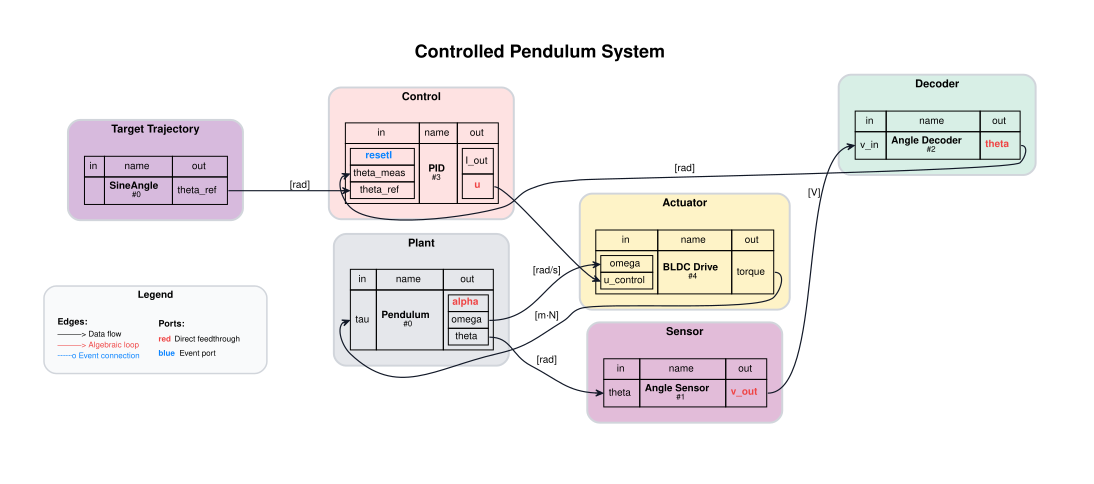

In [38]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()


## Baseline Run (Reference Sensor Settings)

In [17]:
angle_encoder.set_parameters(
    nBits=ref_sensor_params["nBits"],
    samplePeriod=ref_sensor_params["samplePeriod"],
)
angle_decoder.set_parameters(
    nBits=ref_sensor_params["decoder_nBits"],
    samplePeriod=ref_sensor_params["decoder_samplePeriod"],
)

t = 0.0
dt = 0.001
t_end = 5

system.run(t, t_end, dt)

print(f"Simulation config → dt [s]: {dt}, t_end [s]: {t_end}, nBits: {ref_sensor_params['nBits']}, samplePeriod [s]: {ref_sensor_params['samplePeriod']}")


Simulation config → dt [s]: 0.001, t_end [s]: 5, nBits: 10, samplePeriod [s]: 0.01


## Collect Results

In [18]:
history = system.get_history()

ref_history = history["SineAngle"]
t_ref, data = ref_history
theta_ref = data["theta_ref"]

pendulum_history = history["Pendulum"]
t_pendulum, data = pendulum_history
theta_pendulum = data["theta"]

decoder_hist = angle_decoder.get_history()
t_decoder = decoder_hist["theta"]["time"]
theta_decoder = decoder_hist["theta"]["values"]


## Plot Styles

## Plot: Baseline Tracking vs Reference
This baseline uses the reference sensor settings.

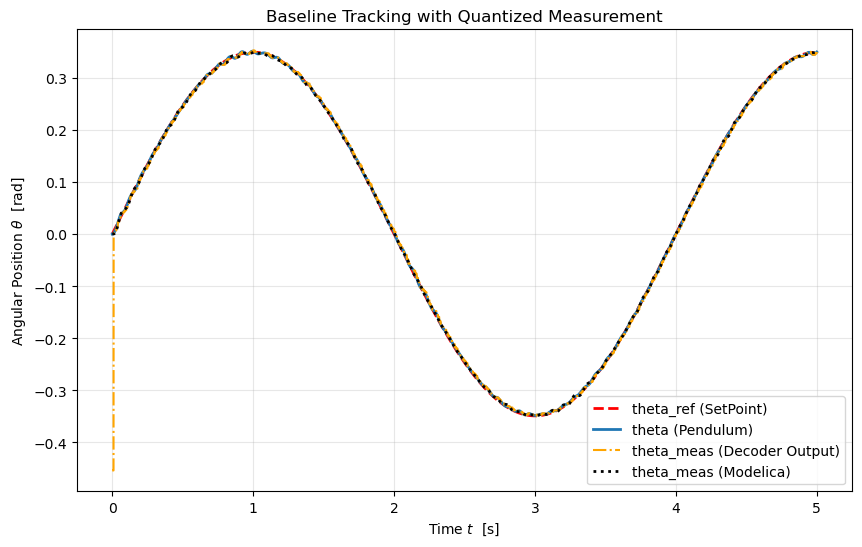

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref, theta_ref, label="theta_ref (SetPoint)", color="red", linestyle="--", linewidth=2)
plt.plot(t_pendulum, theta_pendulum, label="theta (Pendulum)", linewidth=2)
plt.plot(t_decoder, theta_decoder, label="theta_meas (Decoder Output)", color="orange", linestyle="-.")
plt.plot(ref_sol['time'], ref_sol['theta'], label="theta_meas (Modelica)", color='black', linestyle=':', linewidth=2)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Baseline Tracking with Quantized Measurement")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


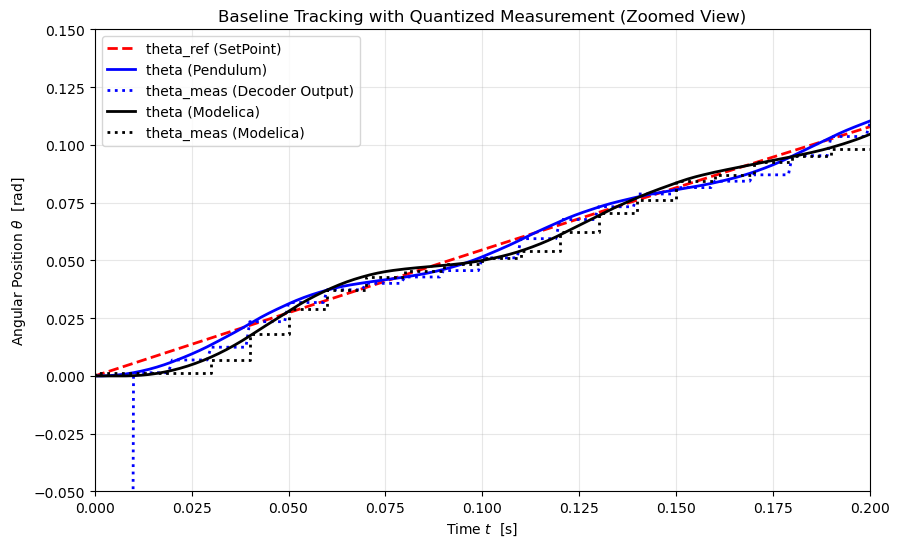

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref, theta_ref, label="theta_ref (SetPoint)", color="red", linestyle="--", linewidth=2)
plt.plot(t_pendulum, theta_pendulum, label="theta (Pendulum)", linewidth=2, color='blue', linestyle='-')
plt.plot(t_decoder, theta_decoder, label="theta_meas (Decoder Output)", color="blue", linestyle=":", linewidth=2)
plt.plot(ref_sol['time'], ref_sol['theta'], label="theta (Modelica)", color='black', linestyle='-', linewidth=2)
plt.plot(ref_sol['time'], ref_sol['theta_meas'], label="theta_meas (Modelica)", color='black', linestyle=':', linewidth=2)
plt.xlim(0, 0.2)
plt.ylim(-0.05, 0.15)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Baseline Tracking with Quantized Measurement (Zoomed View)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Experiment Design
We vary the ADC resolution and sampling period while keeping all other parameters fixed.

### Helper: Run a Quantization Case

In [21]:
def run_quantization_case(label: str, n_bits: int, sample_period: float, dt: float = 0.01):
    system.reset()

    angle_encoder.set_parameters(nBits=n_bits, samplePeriod=sample_period)
    angle_decoder.set_parameters(nBits=n_bits, samplePeriod=sample_period)

    system.initialize(t0=0.0)

    t = 0.0
    t_end = 5

    system.run(t, t_end, dt)

    print(f"{label} → dt [s]: {dt}, nBits: {n_bits}, samplePeriod [s]: {sample_period}")

    dec_hist = angle_decoder.get_history()
    t_dec = dec_hist["theta"]["time"]
    theta_dec = dec_hist["theta"]["values"]

    pendulum_history = history["Pendulum"]
    t_pendulum, data = pendulum_history
    theta_pendulum = data["theta"]

    return {
        "label": label,
        "t_dec": t_dec,
        "theta_dec": theta_dec,
        "t_pendulum": t_pendulum,
        "theta_pendulum": theta_pendulum,
    }


## Quantization Cases

In [22]:
case_high = run_quantization_case(label="High (12-bit, 5 ms)",
                                  n_bits=12,
                                  sample_period=0.005,
                                  dt=0.001)
case_low = run_quantization_case(label="Low (8-bit, 20 ms)",
                                 n_bits=8,
                                 sample_period=0.02, dt=0.001)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

## Plot: Decoder Outputs
This plot shows how sampling and quantization affect the decoded angle.

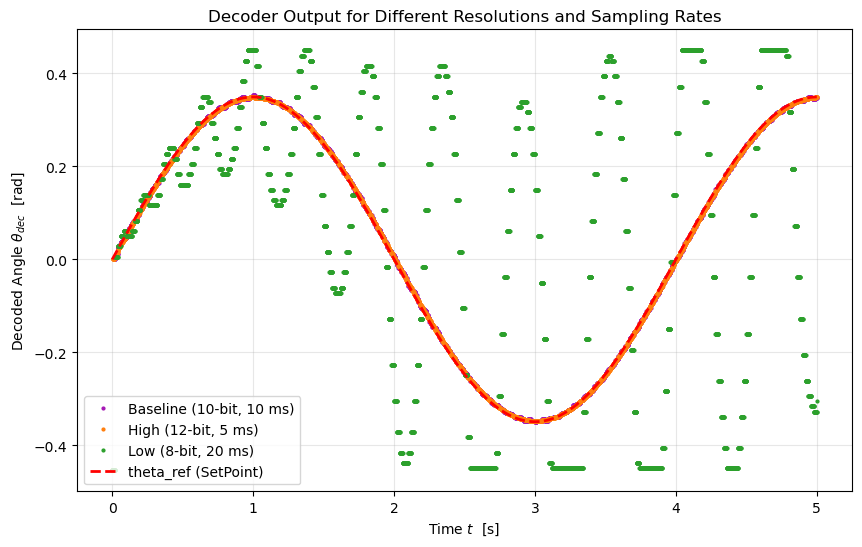

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(t_decoder, theta_decoder, label="Baseline (10-bit, 10 ms)", color="#a518b5", linestyle="None", marker="o", markersize=2)
plt.plot(case_high['t_dec'], case_high['theta_dec'], label=case_high['label'], color="#ff7f0e", linestyle="None", marker="o", markersize=2)
plt.plot(case_low['t_dec'], case_low['theta_dec'], label=case_low['label'], color="#2ca02c", linestyle="None", marker="o", markersize=2)
plt.plot(t_ref, theta_ref, label="theta_ref (SetPoint)", color="red", linestyle="--", linewidth=2)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Decoded Angle $\theta_{dec}$  [rad]")
plt.title("Decoder Output for Different Resolutions and Sampling Rates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

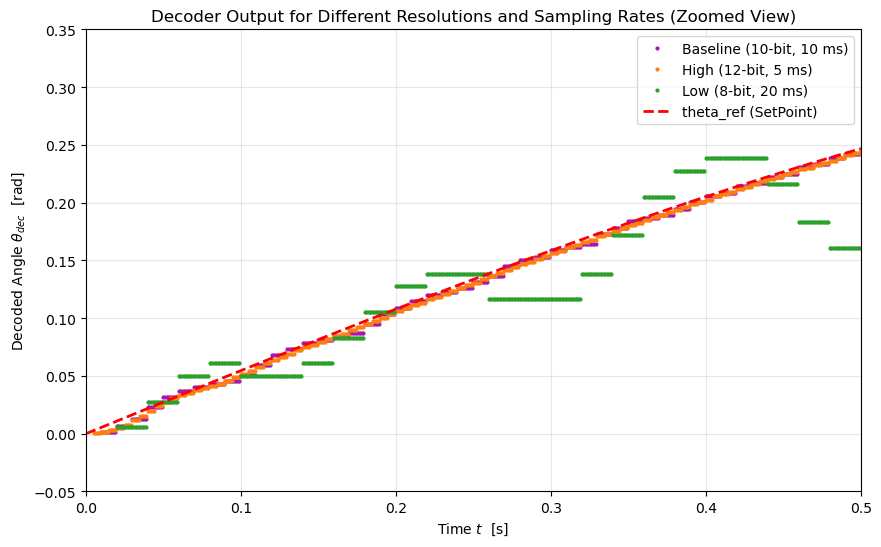

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(t_decoder, theta_decoder, label="Baseline (10-bit, 10 ms)", color="#a518b5", linestyle="None", marker="o", markersize=2)
plt.plot(case_high['t_dec'], case_high['theta_dec'], label=case_high['label'], color="#ff7f0e", linestyle="None", marker="o", markersize=2)
plt.plot(case_low['t_dec'], case_low['theta_dec'], label=case_low['label'], color="#2ca02c", linestyle="None", marker="o", markersize=2)
plt.plot(t_ref, theta_ref, label="theta_ref (SetPoint)", color="red", linestyle="--", linewidth=2)
plt.xlim(0, 0.5)
plt.ylim(-0.05, 0.35)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Decoded Angle $\theta_{dec}$  [rad]")
plt.title("Decoder Output for Different Resolutions and Sampling Rates (Zoomed View)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary
- Higher resolution and faster sampling reduce quantization artifacts in `theta_meas`.
- Control performance degrades at low resolution and slow sampling.